## Validation against ADCP data

Contains comparision of model output to ADCP data by calculating metrics and visualizing data.

In [31]:
from pathlib import Path
import sys
import os

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import helpers
from modules import metrics
from modules import read_files as read
from modules import ADCP as custom

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from utide import solve, reconstruct

### Configuration

In [3]:
run_name = 'validation'                                     # set run name for output
rugosity_bottom = 0.0010
rugosity_wind = 0.0025    
note = ''  
    
output_file_vel = '../../results/validation/ADCP/ADCP_vel_metrics.xlsx'
output_file_harmonics = '../../results/validation/ADCP/ADCP_harmonics_metrics.xlsx'

start_date = '2023-04-13'
end_date = '2023-05-31'

# model output
dir_model_output = '../../data/model_output/L3'
folder_name = run_name
base_name = 'layer' 

# ADCP data
dir_ADCP_upper = "../../data/ADCP/ADCP_upper_11.csv"
dir_ADCP_lower = "../../data/ADCP/ADCP_lower_11.csv"
dir_ADCP_pressure = "../../data/ADCP/ADCP_pressure_11.csv"

### Reading files

In [4]:
# model output
all_results = read.read_files(base_dir=dir_model_output, folder=folder_name, name=base_name)

# ADCP data
ADCP_upper = pd.read_csv(dir_ADCP_upper)
ADCP_lower = pd.read_csv(dir_ADCP_lower)
ADCP_pressure = pd.read_csv(dir_ADCP_pressure)

ADCP_upper = ADCP_upper.set_index('date')
ADCP_lower = ADCP_lower.set_index('date')
ADCP_pressure = ADCP_pressure.set_index('date')

# make sure time periods match
ADCP_upper = ADCP_upper.loc[start_date:end_date]
ADCP_lower = ADCP_lower.loc[start_date:end_date]
ADCP_pressure = ADCP_pressure.loc[start_date:end_date]
ADCP_upper.index = pd.to_datetime(ADCP_upper.index)
ADCP_lower.index = pd.to_datetime(ADCP_lower.index)
ADCP_pressure.index = pd.to_datetime(ADCP_pressure.index)

### Interpolation of model output layers to ADCP bins and layers

In [5]:
# define the depth of each layer (from vertical geometry of model)
layer_depths = {
    34: 1, 33: 3, 32: 6, 31: 10,
    30: 15, 29: 20, 28: 25, 27: 30
}

total_depth = 30.0 # total depth at the location

# compute layer altitudes to match the convention of the ADCP's range
layer_altitudes = {
    layer: total_depth - depth
    for layer, depth in layer_depths.items()
}

bottom_end = 30  # this is not the actual bottom depth but only the end of the last bin

circular_cols = ("velocity_direction",)

# interpolation to ADCP bins for plotting velocity profiles
bins_full = [
    (2.3, 1.8, 2.8),
    (3.3, 2.8, 3.8),
    (4.3, 3.8, 4.8),
    (5.3, 4.8, 5.8),
    (6.3, 5.8, 6.8),
    (7.3, 6.8, 7.8),
    (8.3, 7.8, 8.8),
    (9.3, 8.8, 9.8),
    (10.3, 9.8, 10.8),
    (11.3, 10.8, 11.8),
    (12.3, 11.8, 12.8),
    (13.3, 12.8, 13.8),
    (14.3, 13.8, 14.8),
    (15.3, 14.8, 15.8),
    (16.3, 15.8, 16.8),
    (17.3, 16.8, 17.8),
    (18.3, 17.8, 18.8),
    (19.3, 18.8, 19.8),
    (20.3, 19.8, 20.8),
    (21.3, 20.8, 21.8),
    (22.3, 21.8, 22.8),
    (23.3, 22.8, 23.8),
    (24.3, 23.8, 24.8),
    (25.3, 24.8, 25.8),
]

# Aggregate a single run's per-layer DataFrames into depth bins.
binned_full = helpers.aggregate_run(
    all_results,
    layer_altitudes,
    bins_full,
    bottom_end,
    circular_cols,
)

# interpolation to ADCP layers for calculating metrics
bins = [
    ("bottom", 0.0,  2.3),
    ("lower",   2.3,  13.3),
    ("upper",   13.3, 24.3),
    ("surface",  24.3, 25.22),
]

# Aggregate a single run's per-layer DataFrames into depth bins.
binned = helpers.aggregate_run(
    all_results,
    layer_depths,
    bins,
    bottom_end,
    circular_cols
)

# Make sure time periods match and choose layers of model output
model_output_lower = binned['lower'].loc[start_date:end_date]
model_output_upper = binned['upper'].loc[start_date:end_date]

### Plotting velocity profiles

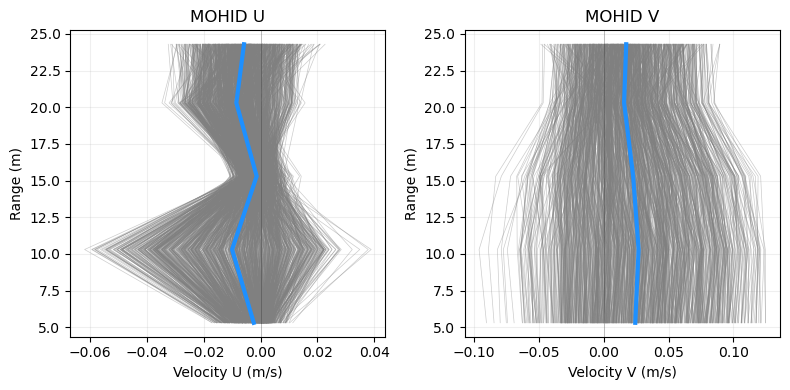

In [6]:
# converting to dataarray
vel_u = helpers.layers_to_dataarray(binned_full, column='velocity_U')
vel_v = helpers.layers_to_dataarray(binned_full, column='velocity_V')


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
custom.plot_profiles(vel_u,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='Velocity U (m/s)',
                     ylabel='Range (m)',
                     title=f'MOHID U',
                     mean_color='blue',
                     ax=axes[0])
custom.plot_profiles(vel_v,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='Velocity V (m/s)',
                     ylabel='Range (m)',
                     title=f'MOHID V',
                     mean_color='blue',
                     ax=axes[1])

# Save figure
plt.savefig(f'../../results/validation/ADCP/MOHID_profile_{run_name}.png', dpi=300, bbox_inches="tight")

plt.show()

### Calculating metrics

In [7]:
# define metrics to calculate
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]
metric_fns_circ = [metrics.rmse_circ, metrics.bias_circ, metrics.mss_circ, metrics.pearson_r_circ]

# calculate metrics for the upper layer
df_upper = metrics.compare_multi_metrics(
    run=model_output_upper, 
    reference=ADCP_upper, 
    metric_fns = metric_fns,
    columns=['velocity_U','velocity_V','velocity_modulus'])
df_upper_circ = metrics.compare_multi_metrics(
    run=model_output_upper, 
    reference=ADCP_upper, 
    metric_fns = metric_fns_circ,
    columns=['velocity_direction'])

# calculate metrics for the lower layer
df_lower = metrics.compare_multi_metrics(
    run=model_output_lower, 
    reference=ADCP_lower, 
    metric_fns = metric_fns,
    columns=['velocity_U','velocity_V','velocity_modulus'])
df_lower_circ = metrics.compare_multi_metrics(
    run=model_output_lower, 
    reference=ADCP_lower, 
    metric_fns = metric_fns_circ,
    columns=['velocity_direction'])

# concat the dataframes
df_upper_circ = df_upper_circ.rename(columns={
    'rmse_circ': 'rmse',
    'bias_circ': 'bias',
    'mss_circ': 'mss',
    'pearson_r_circ': 'pearson_r'
})
df_all_upper = pd.concat([df_upper, df_upper_circ])

df_lower_circ = df_lower_circ.rename(columns={
    'rmse_circ': 'rmse',
    'bias_circ': 'bias',
    'mss_circ': 'mss',
    'pearson_r_circ': 'pearson_r'
})
df_all_lower = pd.concat([df_lower, df_lower_circ])

In [8]:
df_all_upper

,variable,rmse,bias,mss,pearson_r
0,velocity_U,0.054911,0.014628,0.360216,0.221462
1,velocity_V,0.206630,-0.071853,0.493657,0.714589
2,velocity_modulus,0.208848,-0.175466,0.469782,0.415501
0,velocity_direction,68.189863,3.159884,0.844231,0.028078


In [9]:
df_all_lower

,variable,rmse,bias,mss,pearson_r
0,velocity_U,0.048675,0.017226,0.408736,0.283098
1,velocity_V,0.186330,-0.072399,0.472035,0.703145
2,velocity_modulus,0.189363,-0.159203,0.460996,0.421896
0,velocity_direction,67.071190,-8.091299,0.839993,0.120615


### Plot current roses

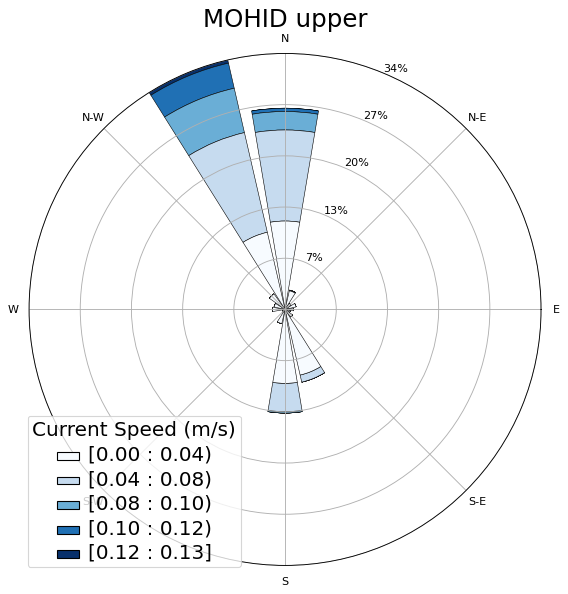

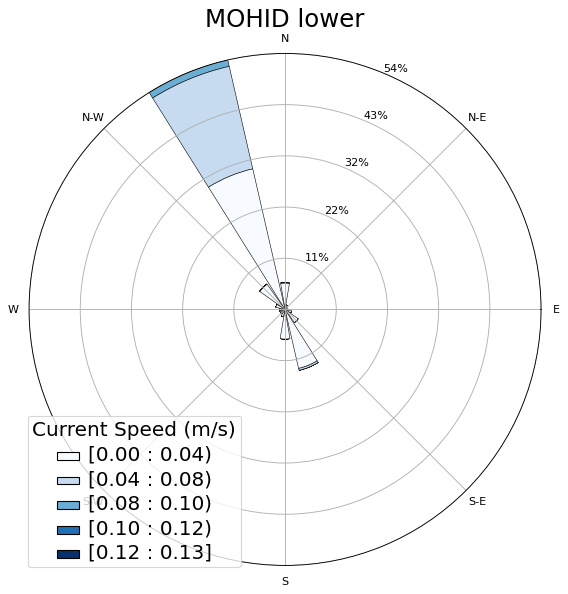

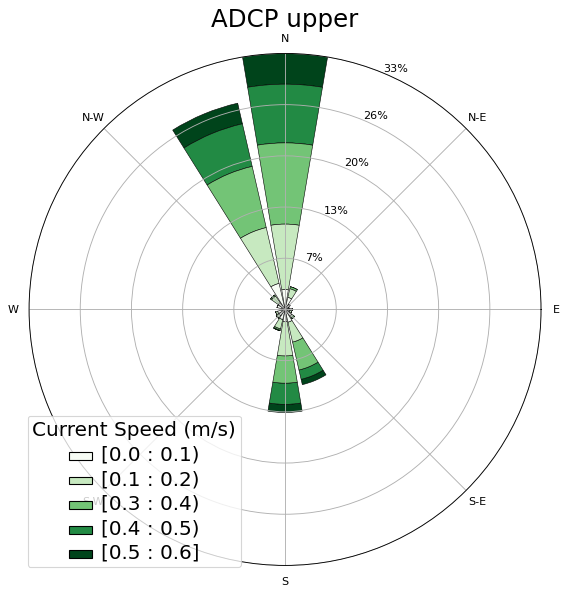

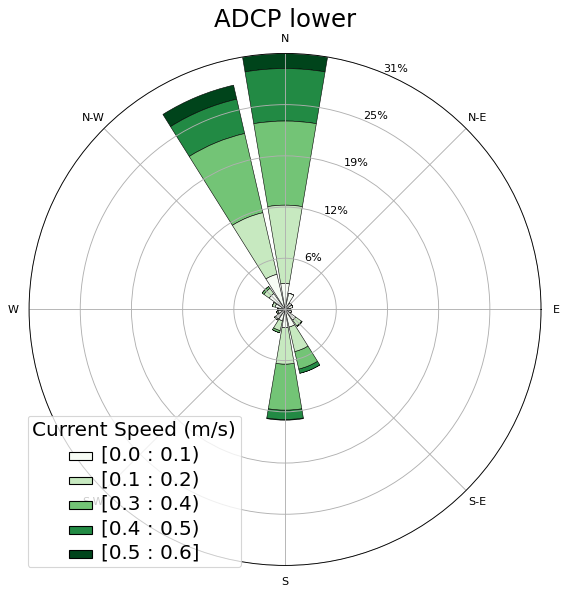

<WindroseAxes: title={'center': 'ADCP lower'}>

In [32]:
bins_model=[0, 0.04, 0.08, 0.10, 0.12] 
labels_model = [
    '[0.00 : 0.04)',
    '[0.04 : 0.08)',
    '[0.08 : 0.10)',
    '[0.10 : 0.12)',
    '[0.12 : 0.13]']

bins_ADCP=[0, 0.1, 0.2, 0.3, 0.4] 
labels_ADCP = [
    '[0.0 : 0.1)',
    '[0.1 : 0.2)',
    '[0.3 : 0.4)',
    '[0.4 : 0.5)',
    '[0.5 : 0.6]']

custom.plot_rose(model_output_upper['velocity_direction'], model_output_upper['velocity_modulus'], bins=bins_model, labels = labels_model, title='MOHID upper', cmap='Blues')
custom.plot_rose(model_output_lower['velocity_direction'], model_output_lower['velocity_modulus'], bins=bins_model, labels = labels_model, title='MOHID lower', cmap='Blues')

custom.plot_rose(ADCP_upper['velocity_direction'], ADCP_upper['velocity_modulus'], bins=bins_ADCP, labels = labels_ADCP, title='ADCP upper', cmap='Greens')
custom.plot_rose(ADCP_lower['velocity_direction'], ADCP_lower['velocity_modulus'], bins=bins_ADCP, labels = labels_ADCP, title='ADCP lower', cmap='Greens')



In [11]:
print(
    'model upper max', model_output_upper['velocity_modulus'].max(), '\n',
    'model lower max', model_output_lower['velocity_modulus'].max(), '\n',
    'ADCP upper max', ADCP_upper['velocity_modulus'].max(), '\n',
    'ADCP lower max', ADCP_lower['velocity_modulus'].max(), '\n'
)

print(
    'model upper mean', model_output_upper['velocity_modulus'].mean(), '\n',
    'model lower mean', model_output_lower['velocity_modulus'].mean(), '\n',
    'ADCP upper mean', ADCP_upper['velocity_modulus'].mean(), '\n',
    'ADCP lower mean', ADCP_lower['velocity_modulus'].mean(), '\n'
)

model upper max 0.12699092184973612 
 model lower max 0.09658338486396746 
 ADCP upper max 0.5606790177974891 
 ADCP lower max 0.4826607189621154 

model upper mean 0.0406923877927626 
 model lower mean 0.02764446002740421 
 ADCP upper mean 0.21619773865676326 
 ADCP lower mean 0.1868308037213034 



### Tidal harmonics

In [11]:
# construct coefficient for model ouput water level
t_wl = all_results[34].index 
wl = all_results[34]['water_level']
coef_wl = solve(t_wl, wl, lat=37, verbose=False, trend=True)

# construct coefficient for ADCP pressure

t_p = ADCP_pressure.index 
p = ADCP_pressure['pressure']
coef_p = solve(t_p, p, lat=37, verbose=False, trend=True)

# tidal harmonics
harmonics_model = pd.DataFrame({
    "constituent": coef_wl.name,
    "freq_cph": coef_wl.aux.frq,
    "phase_deg": coef_wl.g,
    "amplitude": coef_wl.A,
    "SNR": coef_wl.SNR
})

harmonics_ADCP = pd.DataFrame({
    "constituent": coef_p.name,
    "freq_cph": coef_p.aux.frq,
    "phase_deg": coef_p.g,
    "amplitude": coef_p.A,
    "SNR": coef_p.SNR
})

# save only those with higher singal to noise ratio
harmonics_model = harmonics_model[harmonics_model["SNR"] > 10]
harmonics_ADCP = harmonics_ADCP[harmonics_ADCP["SNR"] > 10]

# save only common constituens
common_constituents = set(harmonics_ADCP['constituent']).intersection(
    harmonics_model['constituent']
)

harmonics_ADCP = harmonics_ADCP[
    harmonics_ADCP['constituent'].isin(common_constituents)
].copy()

harmonics_model = harmonics_model[
    harmonics_model['constituent'].isin(common_constituents)
].copy()

harmonics_ADCP = harmonics_ADCP.sort_values('freq_cph').reset_index(drop=True)
harmonics_model = harmonics_model.sort_values('freq_cph').reset_index(drop=True)

In [12]:
harmonics_metrics_circ = metrics.compare_multi_metrics(
    run= harmonics_model, 
    reference= harmonics_ADCP,
    metric_fns = metric_fns_circ,
    columns=['phase_deg'])

harmonics_metrics = metrics.compare_multi_metrics(
    run= harmonics_model, 
    reference= harmonics_ADCP,
    metric_fns = metric_fns,
    columns=['amplitude'])

harmonics_metrics_circ = harmonics_metrics_circ.rename(columns={
    'rmse_circ': 'rmse',
    'bias_circ': 'bias',
    'mss_circ': 'mss',
    'pearson_r_circ': 'pearson_r'
})
harmonics_metrics_all = pd.concat([harmonics_metrics_circ,harmonics_metrics])
harmonics_metrics_all


,variable,rmse,bias,mss,pearson_r
0,phase_deg,78.462607,-25.388352,0.792245,-0.043573
0,amplitude,0.006161,0.002482,0.999633,0.999385


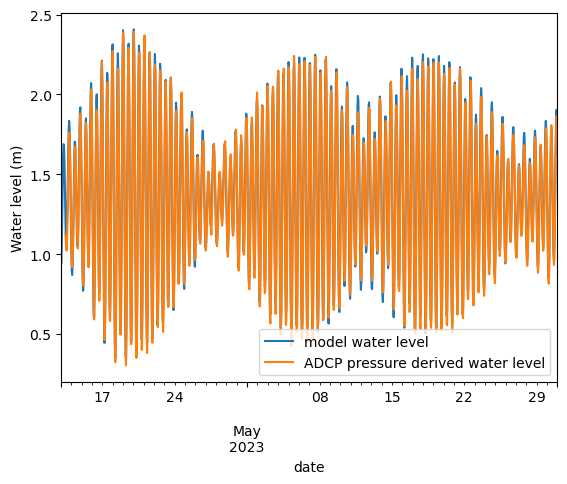

In [ ]:
# visualize water level from model and derived from ADCP pressure
wl_ADCP = ADCP_pressure['pressure'] -27.75
model_output_upper['water_level'].plot(label='model water level')
wl_ADCP.plot(label = 'ADCP pressure derived water level')
plt.ylabel('Water level (m)')
plt.legend()

### Export results of metrics

In [20]:
df_all_upper['Run'] = run_name
df_all_upper['rugosity_bottom'] = rugosity_bottom
df_all_upper['rugosity_wind'] = rugosity_wind
df_all_upper['note'] = note
df_all_upper['Layer'] = 'upper'

df_all_lower['Run'] = run_name
df_all_lower['rugosity_bottom'] = rugosity_bottom
df_all_lower['rugosity_wind'] = rugosity_wind
df_all_lower['note'] = note
df_all_lower['Layer'] = 'lower'

harmonics_metrics_all['Run'] = run_name
harmonics_metrics_all['rugosity_bottom'] = rugosity_bottom
harmonics_metrics_all['rugosity_wind'] = rugosity_wind
harmonics_metrics_all['note'] = note

In [22]:
# Export metrics of upper and lower layer

# Get all variables from one of the dataframes
for variable in df_all_upper["variable"]:
    globals()[f"{variable}"] = df_all_upper[df_all_upper["variable"] == variable].reset_index(drop=True)

variables = df_all_lower["variable"]

file_exists = os.path.exists(output_file_vel)

# If file exists, open in append mode.
# If not, create a new file.
mode = "a" if file_exists else "w"

with pd.ExcelWriter(
    output_file_vel,
    engine="openpyxl",
    mode=mode,
    if_sheet_exists="replace" if file_exists else None
) as writer:

    for variable in variables:
        df_lower_variable = df_all_lower[
            df_all_lower["variable"] == variable
        ].copy()

        df_upper_variable = df_all_upper[
            df_all_upper["variable"] == variable
        ].copy()

        df_new = pd.concat(
            [df_lower_variable, df_upper_variable],
            ignore_index=True
        )

        sheet_name = str(variable)[:31]

        if file_exists:
            try:
                df_existing = pd.read_excel(output_file_vel, sheet_name=sheet_name)

                df_final = pd.concat(
                    [df_existing, df_new],
                    ignore_index=True
                )

            except ValueError:
                # Sheet does not exist yet
                df_final = df_new
        else:
            df_final = df_new

        df_final.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

In [23]:
# Export metrics of harmonics
if os.path.exists(output_file_harmonics):
    existing = pd.read_excel(output_file_harmonics)
    # Add the new run
    results = pd.concat([existing, harmonics_metrics_all], ignore_index=True)
else:
    results = harmonics_metrics_all

# Save the updated table
results.to_excel(output_file_harmonics, index=False)
